Develop end-to-end Machine Learning regression system that predicts an nightly rental Air-BnB property in New York City

In [68]:
import pandas as pd
import numpy as np

In [69]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
air=pd.read_excel("xl.xlsx")

In [73]:
air.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
29995,129995,Private room in Fordham,14342,David,Bronx,Fordham,40.83925,-73.98873,Private room,45,1,37,2017-02-26,1.01,1,167
29996,129996,Private room in Brooklyn Heights,9804,Chris,Brooklyn,Brooklyn Heights,40.68524,-73.93364,Private room,146,1,34,2017-02-05,1.19,20,217
29997,129997,Private room in Harlem,14462,James,Manhattan,Harlem,40.68470,-74.01788,Private room,196,1,28,2018-02-15,0.51,1,221
29998,129998,Entire home/apt in Upper West Side,58227,Daniel,Manhattan,Upper West Side,40.81049,-73.92540,Entire home/apt,283,1,32,2017-08-21,0.33,1,99
29999,129999,Entire home/apt in East Village,39411,Alex,Manhattan,East Village,40.73398,-73.96457,Entire home/apt,317,1,34,2018-08-31,0.37,1,64


In [74]:
air.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
29995,129995,Private room in Fordham,14342,David,Bronx,Fordham,40.83925,-73.98873,Private room,45,1,37,2017-02-26,1.01,1,167
29996,129996,Private room in Brooklyn Heights,9804,Chris,Brooklyn,Brooklyn Heights,40.68524,-73.93364,Private room,146,1,34,2017-02-05,1.19,20,217
29997,129997,Private room in Harlem,14462,James,Manhattan,Harlem,40.68470,-74.01788,Private room,196,1,28,2018-02-15,0.51,1,221
29998,129998,Entire home/apt in Upper West Side,58227,Daniel,Manhattan,Upper West Side,40.81049,-73.92540,Entire home/apt,283,1,32,2017-08-21,0.33,1,99
29999,129999,Entire home/apt in East Village,39411,Alex,Manhattan,East Village,40.73398,-73.96457,Entire home/apt,317,1,34,2018-08-31,0.37,1,64


tail = get last entries of the given data 

In [75]:
air.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000.000000,30000.000000,30000.000000
mean,114999.500000,30499.829533,40.711028,-73.952032,200.651300,3.141967,34.968800,2017-12-14 03:01:52.320000,0.902823,3.501900,182.132467
min,100000.000000,1001.000000,40.462010,-74.273060,20.000000,1.000000,12.000000,2016-06-11 00:00:00,0.000000,1.000000,0.000000
25%,107499.750000,15625.000000,40.654855,-73.997580,133.000000,1.000000,31.000000,2017-03-15 00:00:00,0.360000,1.000000,120.000000
50%,114999.500000,30467.500000,40.715915,-73.960685,191.000000,2.000000,35.000000,2017-12-17 00:00:00,0.710000,1.000000,182.000000
75%,122499.250000,45313.000000,40.762930,-73.918170,263.000000,3.000000,39.000000,2018-09-14 00:00:00,1.240000,3.000000,245.000000
max,129999.000000,59999.000000,40.948860,-73.612020,540.000000,30.000000,64.000000,2019-06-15 00:00:00,7.080000,50.000000,363.000000
std,8660.398374,17067.658207,0.068907,0.076388,92.424114,4.600621,5.891122,NaN,0.737399,7.562418,81.596375


describe()= stastiscal summary of a numerical data 
 count = number of values
 mean  = average
 min  = minimum value
 std  = standard deviation
 25%	First quartile
 50%	    Median
 75%	   Third quartile

In [76]:
air.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              30000 non-null  int64         
 1   name                            29992 non-null  str           
 2   host_id                         30000 non-null  int64         
 3   host_name                       29988 non-null  str           
 4   neighbourhood_group             30000 non-null  str           
 5   neighbourhood                   30000 non-null  str           
 6   latitude                        30000 non-null  float64       
 7   longitude                       30000 non-null  float64       
 8   room_type                       30000 non-null  str           
 9   price                           30000 non-null  int64         
 10  minimum_nights                  30000 non-null  int64         
 11  number_of_rev

In [77]:
air.isna().sum()

id                                 0
name                               8
host_id                            0
host_name                         12
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

since name and host id doesnt depends on price so no need of taking null values of name and host id


In [78]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
air.duplicated().sum()

np.int64(0)

there is no duplicate values 

In [81]:
display(air["price"].quantile([0,.25,.5,.75,.9,.95,.99,1]).to_frame("price"))

,price
0.00,20.0
0.25,133.0
0.50,191.0
0.75,263.0
0.90,333.0
0.95,365.0
0.99,418.0
1.00,540.0


find unusual/extreme prices (outliers) and understand the distribution of prices.

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

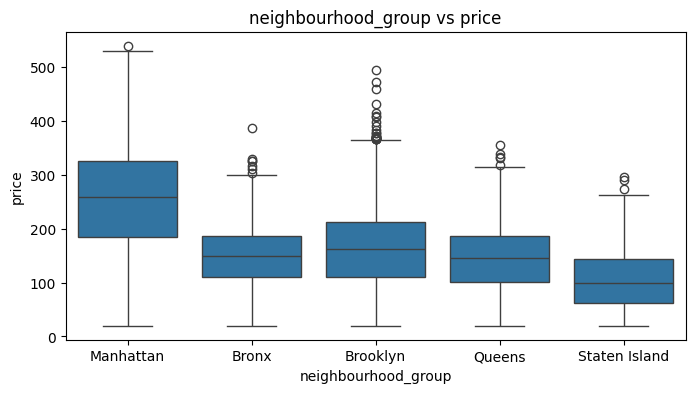

In [83]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=air,
    x="neighbourhood_group",
    y="price"
)

plt.title("neighbourhood_group vs price")
plt.xlabel("neighbourhood_group")
plt.ylabel("price")
plt.show()

this defines average pricing in the around the neighbourhood this show outlairs 

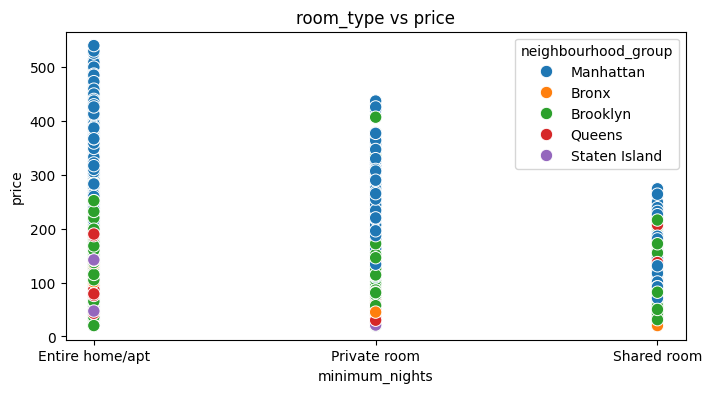

In [84]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=air,
    x="room_type",
    y="price",
    hue ="neighbourhood_group",
    s= 80
)

plt.title("room_type vs price")
plt.xlabel("minimum_nights")
plt.ylabel("price")
plt.show()

creates a scatterr plot to compare Airbnb prices across different room types ,with colors showing the neighbouring group

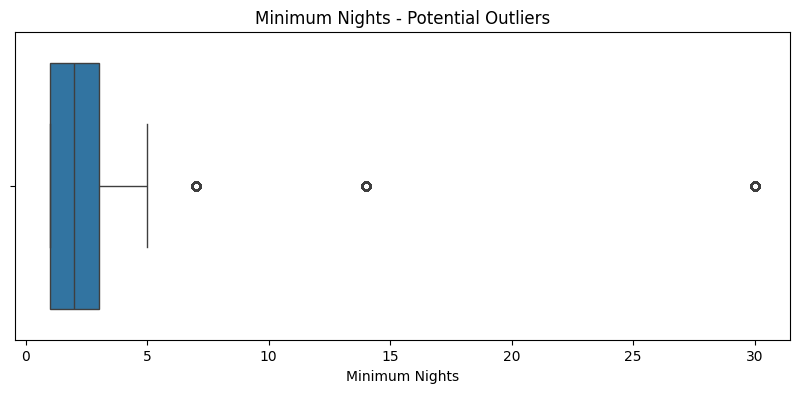

Minimum Nights: 


,minimum_nights
0.00,1.0
0.25,1.0
0.50,2.0
0.75,3.0
0.90,7.0
0.99,30.0
1.00,30.0


In [85]:
plt.figure(figsize = (10, 4))
sns.boxplot(x = air["minimum_nights"])
plt.title("Minimum Nights - Potential Outliers")
plt.xlabel("Minimum Nights")
plt.show()

print("Minimum Nights: ")
display(air["minimum_nights"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99, 1]).to_frame("minimum_nights"))

Minimum Nights on Rental
People stay inside a rental property on a average of 2 days.
Longest Stay: 30 days
Shortest Stay : 1 day

A. Univariate Analysis
The simplest form of statistical analysis where data involves only one variable at a time.

We shall only focus on the following attributes in the DataFrame to find:

Outliers
Patterns
Observations
price (Boxplot and Histogram/KDE)
minimum_nights (Box plot)
room_type (Count plot)
neighbourhood_group (Count plot)
number_of_reviews (Histogram/KDE)
availability_365 (Histogram/KDE)
reviews_per_month (Boxplot and Histogram/KDE)

1. Price Distribution
Are outliers present? : YES
Lower Bound of Boxplot : -62.0
Upper Bound of Boxplot: 458.0
Total Number of Outliers: 66
The boxplot indicates the presence of potential high-value outliers. The upper outlier boundary is approximately 458, while the maximum observed price is 540. The distribution is positively/right skewed due to the concentration of higher-priced observations beyond the upper whisker.

Similiarly, the histogram also point towards rental prices being concentrated mainly in the lower-to-middle price range, with fewer listings at higher prices. The distribution is positively/right-skewed, indicating the presence of relatively expensive properties. This is consistent with the potential high-value outliers identified in the boxplot.



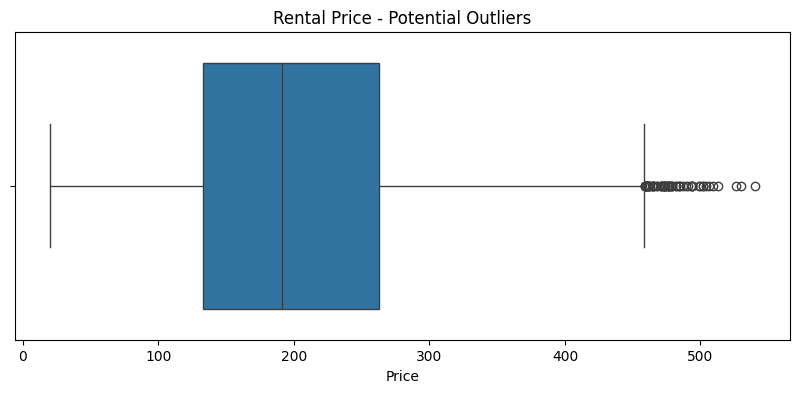

Price quantities: 


,price
0.00,20.0
0.25,133.0
0.50,191.0
0.75,263.0
0.90,333.0
0.99,418.0
1.00,540.0


In [86]:
# Price Boxplot
plt.figure(figsize = (10, 4))
sns.boxplot(x = air["price"])
plt.title("Rental Price - Potential Outliers")
plt.xlabel("Price")
plt.show()

print("Price quantities: ")
display(air["price"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99, 1]).to_frame("price"))

In [87]:
# Finding Price Outliers
Q1 = air["price"].quantile(0.25)
Q3 = air["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)

outliers = air[
    (air["price"] < lower_bound) |
    (air["price"] > upper_bound)
]

print("Number of Outliers: ", len(outliers))


Lower Bound:  -62.0
Upper Bound:  458.0
Number of Outliers:  66


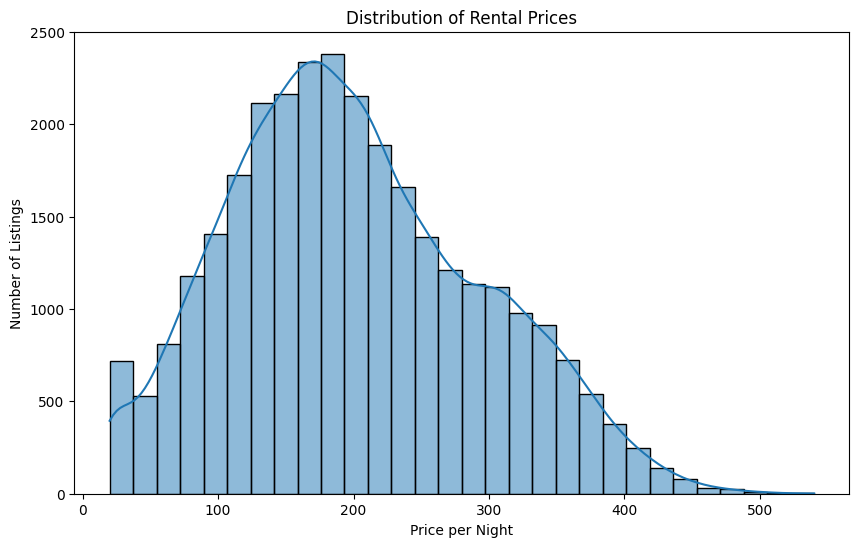

In [88]:
# Price Histogram/KDE
plt.figure(figsize=(10, 6))

sns.histplot(
    air['price'],
    bins = 30,
    kde = True
)

plt.title('Distribution of Rental Prices')
plt.xlabel('Price per Night')
plt.ylabel('Number of Listings')
plt.show()

2. Minimum Nights Distribution
The median minimum-night requirement is 2 nights.
Most listings require a minimum stay of 1 to 3 nights
A small number of listings have substantially higher minimum-night requirements, reaching up to 30 nights.


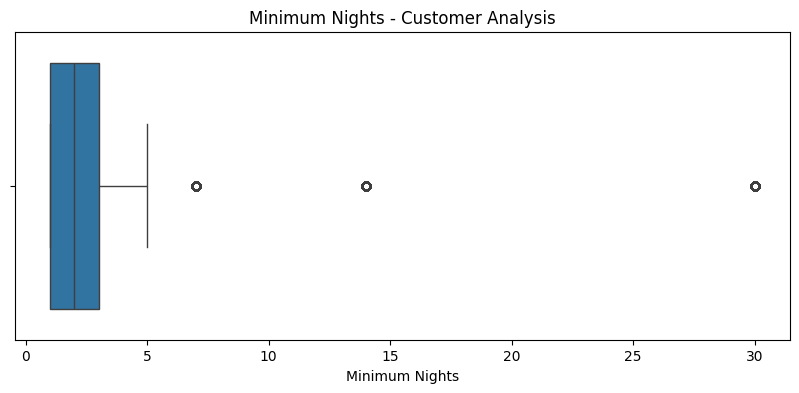

Minimum Nights: 


,minimum_nights
0.00,1.0
0.25,1.0
0.50,2.0
0.75,3.0
0.90,7.0
0.99,30.0
1.00,30.0


In [89]:
# Minimum Nights Boxplot
plt.figure(figsize = (10, 4))
sns.boxplot(x = air["minimum_nights"])
plt.title("Minimum Nights - Customer Analysis")
plt.xlabel("Minimum Nights")
plt.show()

print("Minimum Nights: ")
display(air["minimum_nights"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99, 1]).to_frame("minimum_nights"))

In [90]:
3. Room Type Distribution
Most common room type : Entire home/apt(15584 listings), approx. 51.95%
Least common room type : Shared room (626 listings) , approx. 2.09%
Private room is nearly as common (13790 listings), accounting for approx. 45.97% of the total. Combined, the top two categories represent 97.92% of the dataset.
Shared room represents a tiny fraction of the dataset at just 2.09%
Therefore, the dataset is not evenly distributed across different rental types.


SyntaxError: invalid syntax (2021396356.py, line 1)

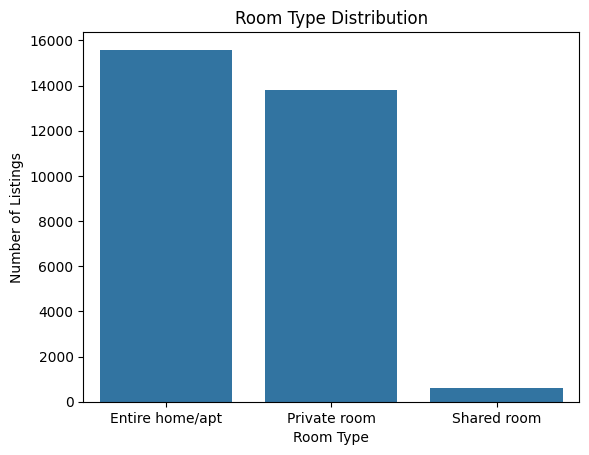

,room_type
room_type,
Entire home/apt,15584
Private room,13790
Shared room,626


In [91]:
# Room type Countplot
sns.countplot(
    data = air,
    x = "room_type"
)

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show()

target_counts = air["room_type"].value_counts()
display(target_counts.to_frame("room_type"))



4. Distribution by Borough/Neighbourhood Group
Manhattan(13233 listings) and Brooklyn(12308 listings) dominate the dataset, accounting for 44.11% and 41.03% respectively. Combined, they represent over 85.14% of all listings.

Queens with 2659 listings holds a moderate share at 8.86%, sitting well behind the top two but significantly ahead of the remaining boroughs.

The Bronx (1208 listings) and Staten Island (592 listings) comprise a small minority of the overall listings, accounting for only 4.03% and 1.97% respectively. Combined, they contribute only 5.76% of all listings

The data is geographically unbalanced, with Manhattan and Brooklyn dominating the listings, meanwhile the Bronx and Staten Island comprise a small minority. Hence, some boroughs are underrepresented in the listings.


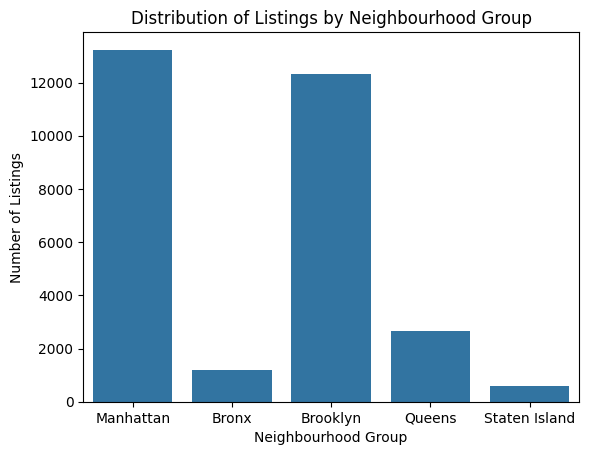

,neighbourhood_group
neighbourhood_group,
Manhattan,13233
Brooklyn,12308
Queens,2659
Bronx,1208
Staten Island,592


In [92]:
# Neighbourhood Group Countplot
sns.countplot(
    data = air,
    x = "neighbourhood_group"
)

plt.title("Distribution of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.show()

target_counts = air["neighbourhood_group"].value_counts()
display(target_counts.to_frame("neighbourhood_group"))

5. Review Distribution
The distribution of the number of reviews is approximately normal (bell-shaped) and roughly symmetric, with the Kernel Density Estimate (KDE) curve closely mirroring a Normal distribution curve.

The peak frequency is approx. 34.98 (since mean is 34.968800 and median(50%) is 35)

The highest individual bin counts reach close to 4,000 listings in the 33–35 review range.(Each bin count covers approx 1.67 number of reviews)

The vast majority of listings fall between approximately 20 and 50 reviews(according to the bell-shaped curve observed in the KDE graph). The overall range spans from a minimum of 12 up to a maximum of 64 reviews.

There are no extreme outliers or heavy long-tail distributions visible, indicating that listings have a tightly bound range of review activity.

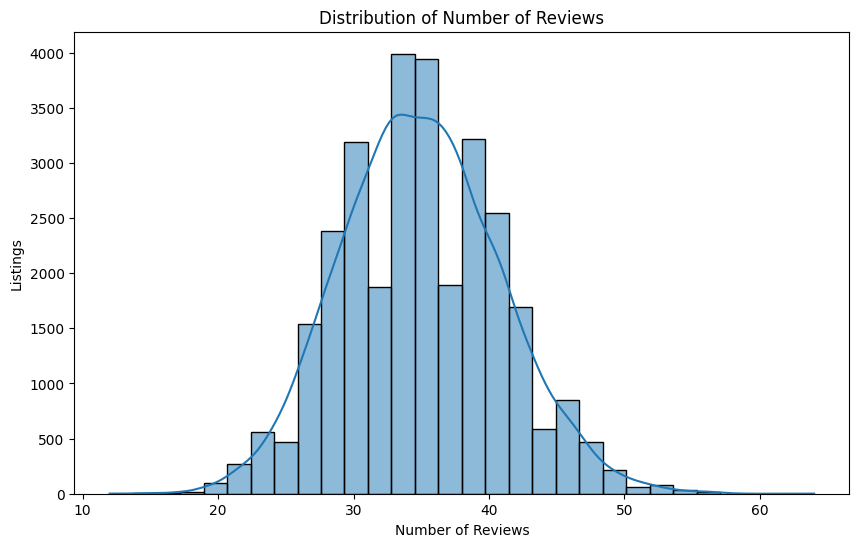

In [93]:
# Number of Reviews Histogram/KDE
plt.figure(figsize=(10, 6))

sns.histplot(
    air['number_of_reviews'],
    bins = 30,
    kde = True
)

plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Listings')
plt.show()

In [94]:
air["number_of_reviews"].describe() # Description of number_of_reviews

count    30000.000000
mean        34.968800
std          5.891122
min         12.000000
25%         31.000000
50%         35.000000
75%         39.000000
max         64.000000
Name: number_of_reviews, dtype: float64

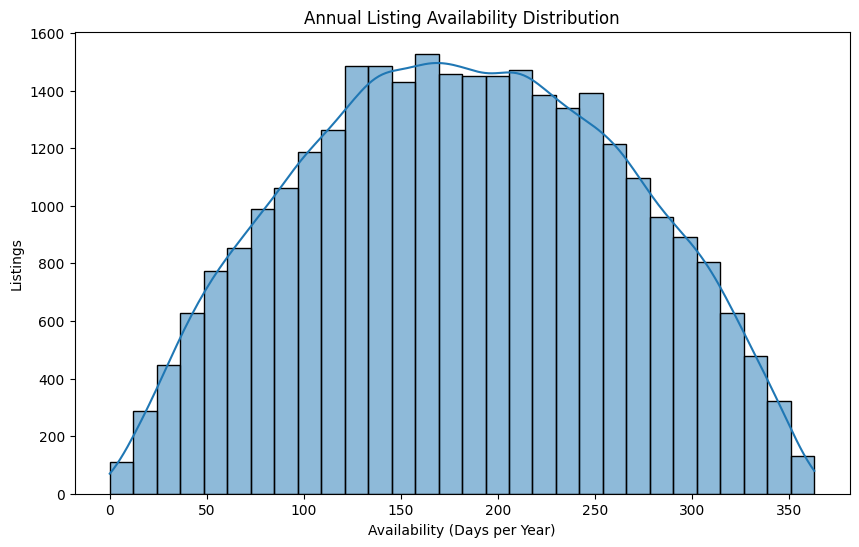

In [95]:
# Availability Histogram/KDE
plt.figure(figsize=(10, 6))

sns.histplot(
    air['availability_365'],
    bins = 30,
    kde = True
)

plt.title('Annual Listing Availability Distribution')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Listings')
plt.show()

In [96]:
air["availability_365"].describe() # Description of availability_365

count    30000.000000
mean       182.132467
std         81.596375
min          0.000000
25%        120.000000
50%        182.000000
75%        245.000000
max        363.000000
Name: availability_365, dtype: float64

7. Reviews per Month Distribution
Are outliers present? : YES
Lower Bound of Boxplot : -0.96
Upper Bound of Boxplot: 2.56
Total Number of Outliers: 1109
The boxplot indicates the presence of potential high-value outliers. The upper outlier boundary is approximately 2.56, while the maximum observed reviews per month is 7.08. The distribution is* positively/right skewed* due to the concentration of higher review frequency observations beyond the upper whisker.

Similarly, the histogram also points towards reviews per month being concentrated mainly in the lower range, with fewer listings at higher frequencies. The distribution is positively/right-skewed, indicating the presence of properties with relatively high review frequencies. This is consistent with the potential high-value outliers identified in the boxplot.

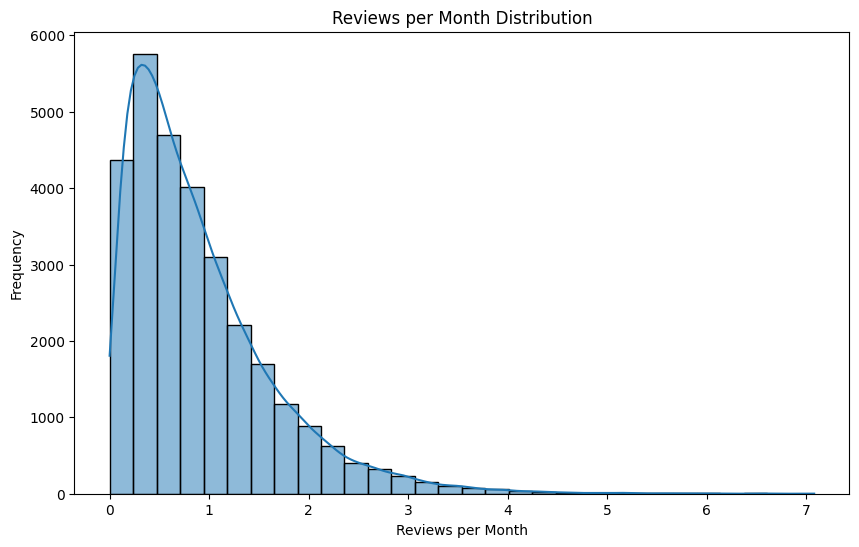

In [97]:
# Reviews Per Month Histogram/KDE
plt.figure(figsize=(10, 6))

sns.histplot(
    air['reviews_per_month'],
    bins = 30,
    kde = True
)

plt.title('Reviews per Month Distribution')
plt.xlabel('Reviews per Month')
plt.ylabel('Frequency')
plt.show()

In [98]:
air["reviews_per_month"].describe() # Description of reviews_per_month

count    30000.000000
mean         0.902823
std          0.737399
min          0.000000
25%          0.360000
50%          0.710000
75%          1.240000
max          7.080000
Name: reviews_per_month, dtype: float64

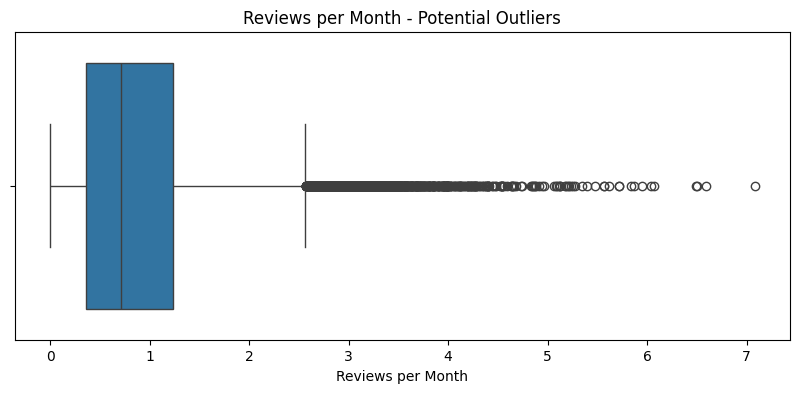

Price quantities: 


,reviews_per_month
0.00,0.00
0.25,0.36
0.50,0.71
0.75,1.24
0.90,1.88
0.99,3.42
1.00,7.08


In [99]:
# Reviews Per Month Boxplot
plt.figure(figsize = (10, 4))
sns.boxplot(x = air["reviews_per_month"])
plt.title("Reviews per Month - Potential Outliers")
plt.xlabel("Reviews per Month")
plt.show()

print("Price quantities: ")
display(air["reviews_per_month"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99, 1]).to_frame("reviews_per_month"))

In [100]:
# Finding Reviews per Month Outliers
Q1 = air["reviews_per_month"].quantile(0.25)
Q3 = air["reviews_per_month"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)

outliers = air[
    (air["reviews_per_month"] < lower_bound) |
    (air["reviews_per_month"] > upper_bound)
]

print("Number of Outliers: ", len(outliers))


Lower Bound:  -0.9600000000000001
Upper Bound:  2.56
Number of Outliers:  1109


. Correlation Heatmap Analysis of Numeric Variables
Here, we analyze the correlation heatmap of numeric variables to understand the linear relationships between the different numerical features in the dataset.

Observations
The correlation matrix includes variables such as price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365, latitude, and longitude.

Price Correlations:

price has a moderate positive correlation with latitude (0.36). This reflects the geographic influence on pricing, where listings further north (such as Manhattan) tend to command higher prices.
price exhibits a weak negative correlation with longitude (-0.20).
price shows virtually no linear correlation with minimum_nights (-0.00), number_of_reviews (0.00), reviews_per_month (-0.01), calculated_host_listings_count (0.01), or availability_365 (-0.00).
Inter-variable Correlations:

Most other numerical feature pairs show correlation coefficients close to 0.00, indicating a lack of linear association between them. For instance, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, and availability_365 are largely independent of one another in linear terms.
A minor positive correlation of 0.09 exists between latitude and longitude, which naturally represents the geographic coordinate layout of the region.
Overall, the correlation heatmap indicates that traditional numerical features (like reviews, stay requirements, and availability) do not have strong linear relationships with price. The most notable linear relationship with price is spatial, captured through geographical coordinates (latitude and longitude).

Conclusion
The correlation analysis demonstrates that geographic location (represented by latitude) has the most notable linear association with rental price, while other numeric operational variables display minimal linear correlation with pricing.

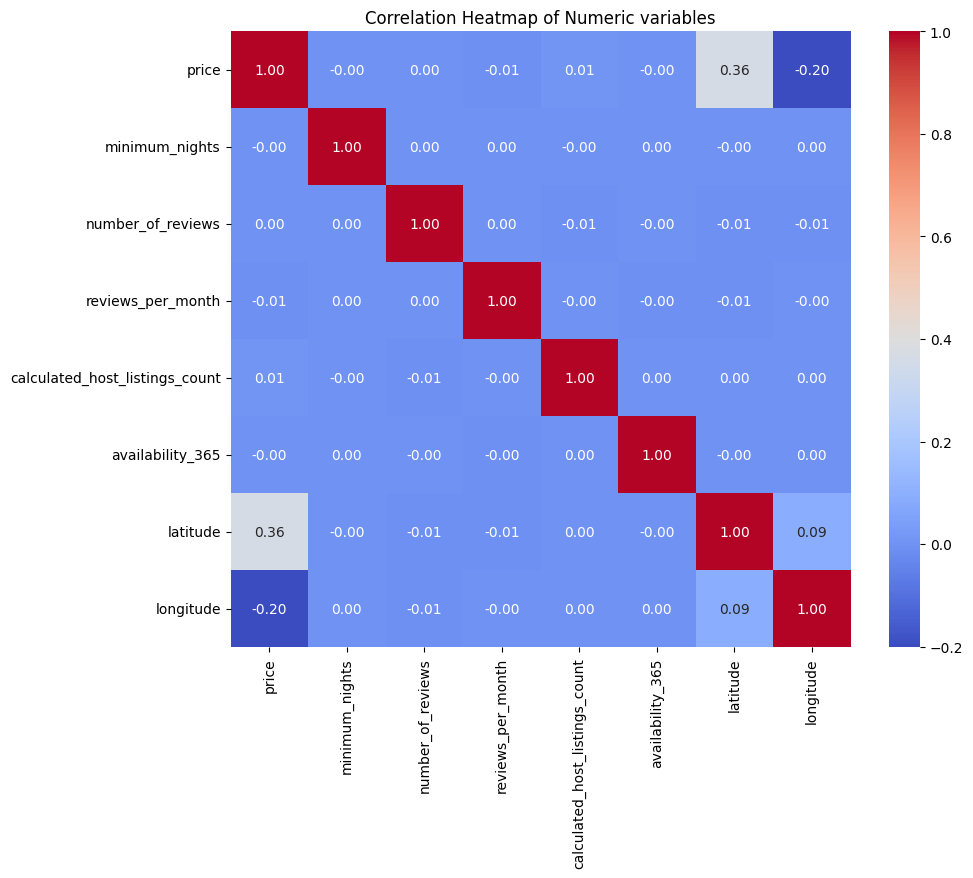

In [101]:
numeric_columns = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'latitude',
    'longitude'
]

plt.figure(figsize = (10, 8))
sns.heatmap(
    air[numeric_columns].corr(),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Heatmap of Numeric variables")
plt.show()

Feature engineering


In [120]:
basic_features=[
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'latitude',
    'longitude'
]

x_basic = air[basic_features].copy()
y=air["price"].copy()

print("X:",x_basic)
print("Y",y)

X:        minimum_nights  number_of_reviews  reviews_per_month  \
0                   7                 31               1.45   
1                   4                 25               0.44   
2                   1                 29               1.27   
3                   1                 29               0.33   
4                   3                 28               0.42   
...               ...                ...                ...   
29995               1                 37               1.01   
29996               1                 34               1.19   
29997               1                 28               0.51   
29998               1                 32               0.33   
29999               1                 34               0.37   

       calculated_host_listings_count  availability_365  latitude  longitude  
0                                   1               217  40.79192  -73.95220  
1                                   1               277  40.80563  -73.87973  
2  

Training: (24000, 7)
Training: (6000, 7)


In [102]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_preprocessor = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

print("Numerical processing pipeline created.")

Numerical processing pipeline created.


In [103]:
from sklearn.preprocessing import OneHotEncoder

categorical_preprocessor = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown = "ignore",
        min_frequency = 5
        ))
])

print("Categorical processing pipeline created.")

Categorical processing pipeline created.


In [104]:
from sklearn.compose import ColumnTransformer

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count",
    "last_review_year",
    "last_review_month"
]

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

combined_preprocessor = ColumnTransformer(
    transformers = [
    ("numeric", numeric_preprocessor, numerical_features),
    ("tcatergorical", categorical_preprocessor, categorical_features)
    ],
    remainder = "drop"                                          
)

print("Combined numerical + categorical preprocessor created.")

Combined numerical + categorical preprocessor created.


In [105]:
# Linear Regression
linear_regression = Pipeline([
    ("preprocessing", combined_preprocessor),
    ("model", LinearRegression())
])


print("Baseline Linear Regression trained")

Baseline Linear Regression trained


In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

random_forest = Pipeline([
    ("preprocessing", combined_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest Regression trained")

Random Forest Regression trained


In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import time

# Function to evaluate regression models
def evaluate_regression(model_name, model, X_train, X_test, y_train, y_test):

    start = time.time()

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    result = {
        "model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
        "training_seconds": time.time() - start
    }

    return result, predictions

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import time
import pandas as pd


def evaluate_regression(model_name, model, x_train, x_test, y_train, y_test):

    start = time.time()

    model.fit(x_train, y_train)

    predictions = model.predict(x_test)

    # Calculate evaluation metrics
    result = {
        "model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions),
        "training_seconds": time.time() - start
    }

    return result, predictions


lr_result, lr_predictions = evaluate_regression("Linear Regression",LinearRegression(),x_train,x_test,y_train,y_test)

rf_result, rf_predictions = evaluate_regression("Random Forest",RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1),x_train,x_test,y_train,y_test)

results = pd.DataFrame([
    lr_result,
    rf_result
])

print("Regression Model Comparison:")
display(results.round(4))

Regression Model Comparison:


,model,MAE,RMSE,R2,training_seconds
0,Linear Regression,67.8550,82.8170,0.1974,0.1171
1,Random Forest,66.3701,81.0121,0.2320,5.8637
